# Phase 14 — Reproducible, Source-Grounded Evaluation

This notebook evaluates the Business Knowledge AI pipeline only when real, auditable inputs exist. It creates a small evaluation dataset from direct evidence in the official OpenStax Introduction to Business source, then computes retrieval metrics from the executed BM25 artifact. It does not manufacture reference answers, dense vectors, reranker output, LLM answers, citations, or evaluation scores.

Generation metrics are defined with a guarded Ragas integration. They run only when valid generated answers, retrieved contexts, and approved source use are available.

**Scope boundary:** this notebook evaluates artifacts; it does not add agents, tool calling, retrieval loops, or LangGraph behavior.


## Evaluation design

| Area | Measures | Current execution rule |
| --- | --- | --- |
| Retrieval | Recall at K, Precision at K, MRR, source-anchored context relevance | Computed from real BM25 rankings and direct OpenStax evidence anchors. |
| Generation | Faithfulness, answer relevance, context utilization | Defined through guarded Ragas/custom paths; not computed without real answer artifacts. |
| Variants | Dense RAG, Hybrid RAG, Hybrid plus Reranking, basic prompting, prompt engineering, deterministic LangGraph RAG | Each variant is reported as evaluated or unavailable with a concrete artifact reason. |

The evaluation labels are not model-written ground truth. Each label names an actual chunk and a directly verifiable quotation from the official textbook.


In [1]:
from __future__ import annotations

import importlib.util
import json
import math
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path('/home/ubuntu/business-knowledge-ai')
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
CHUNKS_PATH = PROCESSED_DIR / 'introduction_to_business_chunks.jsonl'
BM25_PATH = PROCESSED_DIR / 'introduction_to_business_bm25_retrieval_results.json'
SOURCE_PATH = RAW_DIR / 'SOURCE.md'

for required in [CHUNKS_PATH, BM25_PATH, SOURCE_PATH]:
    assert required.exists(), f'Missing required evaluation input: {required}'

print('Project root:', ROOT)
print('Official-source provenance:', SOURCE_PATH)
print('Executed retrieval artifact:', BM25_PATH)


Project root: /home/ubuntu/business-knowledge-ai
Official-source provenance: /home/ubuntu/business-knowledge-ai/data/raw/SOURCE.md
Executed retrieval artifact: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_bm25_retrieval_results.json


In [2]:
def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

def normalize(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip().lower()

chunks = {row['chunk_id']: row for row in read_jsonl(CHUNKS_PATH)}
bm25_runs = json.loads(BM25_PATH.read_text(encoding='utf-8'))
assert len(chunks) == 3018, f'Expected 3,018 source chunks; found {len(chunks)}'
assert len(bm25_runs) == 15, f'Expected 15 BM25 runs; found {len(bm25_runs)}'

source_provenance = SOURCE_PATH.read_text(encoding='utf-8')
print('Chunk count:', len(chunks))
print('BM25 runs:', len(bm25_runs))
print(source_provenance.splitlines()[0])


Chunk count: 3018
BM25 runs: 15
# Source Record — Introduction to Business


## Build a reproducible evidence-anchor dataset

Each example below uses a question already present in the executed BM25 experiment. Its relevance label is a **single explicit source anchor**, not a generated reference answer. The notebook asserts that the quoted evidence exists in the cited OpenStax chunk before saving the dataset.


In [3]:
evaluation_specs = [
    {
        'query_id': 'business-foundations',
        'anchor_chunk_id': 'openstax-introduction-business-p0193-c001',
        'anchor_quote': 'Small businesses play an important role in the U.S. economy, representing about half of U.S. economic output',
        'why_relevant': 'The quotation directly addresses the economic role described by the question.'
    },
    {
        'query_id': 'ownership-choice',
        'anchor_chunk_id': 'openstax-introduction-business-p0143-c001',
        'anchor_quote': 'Will you attract employees? How will the business be taxed, and who will be liable for the company’s debts?',
        'why_relevant': 'The quotation supplies concrete ownership-form selection considerations from the textbook.'
    },
    {
        'query_id': 'management-planning',
        'anchor_chunk_id': 'openstax-introduction-business-p0252-c004',
        'anchor_quote': 'Planning is deciding what needs to be done, identifying when and how it will be done, and determining who should do it.',
        'why_relevant': 'The quotation is the textbook definition of planning used to ground the management question.'
    },
    {
        'query_id': 'marketing-selling',
        'anchor_chunk_id': 'openstax-introduction-business-p0428-c002',
        'anchor_quote': 'marketing encompasses much more than just promotion.',
        'why_relevant': 'The quotation directly distinguishes the broader marketing concept from a visible promotional activity.'
    },
    {
        'query_id': 'financial-statements',
        'anchor_chunk_id': 'openstax-introduction-business-p0563-c001',
        'anchor_quote': 'Finally, individuals analyze these reports and make decisions based on the information in them.',
        'why_relevant': 'The quotation directly states how financial reports support decisions.'
    },
]

question_by_id = {run['query_id']: run['question'] for run in bm25_runs}
evaluation_dataset = []
for spec in evaluation_specs:
    chunk = chunks[spec['anchor_chunk_id']]
    assert normalize(spec['anchor_quote']) in normalize(chunk['text']), (
        f"Evidence quote not found in its claimed source chunk: {spec['anchor_chunk_id']}"
    )
    evaluation_dataset.append({
        'query_id': spec['query_id'],
        'question': question_by_id[spec['query_id']],
        'source_evidence_anchor': {
            'chunk_id': spec['anchor_chunk_id'],
            'page': chunk['page'],
            'chapter': chunk['chapter'],
            'section': chunk['section'],
            'quote': spec['anchor_quote'],
            'official_source': chunk['source']['official_book_url'],
        },
        'label_type': 'direct_official_source_evidence_anchor',
        'why_relevant': spec['why_relevant'],
        'reference_answer': None,
        'reference_answer_reason': 'Not created: this dataset avoids fabricated or model-written ground-truth answers.'
    })

DATASET_OUT = PROCESSED_DIR / 'introduction_to_business_evaluation_dataset.json'
DATASET_OUT.write_text(json.dumps({
    'dataset_name': 'openstax_introduction_to_business_evidence_anchor_eval',
    'dataset_version': '1.0',
    'source_provenance_file': str(SOURCE_PATH.relative_to(ROOT)),
    'labeling_policy': 'Each relevance label is a direct quote verified against a cited official OpenStax chunk; no generated reference answers are stored.',
    'examples': evaluation_dataset,
}, indent=2, ensure_ascii=False), encoding='utf-8')

pd.DataFrame([{
    'query_id': item['query_id'],
    'question': item['question'],
    'anchor_chunk_id': item['source_evidence_anchor']['chunk_id'],
    'page': item['source_evidence_anchor']['page'],
} for item in evaluation_dataset])


,query_id,question,anchor_chunk_id,page
0,business-foundations,What role do businesses play in an economy?,openstax-introduction-business-p0193-c001,193
1,ownership-choice,What factors should an entrepreneur consider w...,openstax-introduction-business-p0143-c001,143
2,management-planning,How does the planning process help managers se...,openstax-introduction-business-p0252-c004,252
3,marketing-selling,How is marketing different from selling?,openstax-introduction-business-p0428-c002,428
4,financial-statements,How do financial statements help business owne...,openstax-introduction-business-p0563-c001,563


## Retrieval metrics

For this evidence-anchor dataset, an item is relevant only if it contains the cited source-anchor chunk. This is a deliberately narrow, reproducible operationalization. **Source-anchored context relevance** is the fraction of the returned context that matches the dataset's verified evidence anchors; it is not an LLM-as-judge score.

Recall at K measures whether an anchor appears in the first K results. Precision at K and source-anchored context relevance are identical here because each query has one evidence anchor. MRR uses the anchor's first observed rank.


In [4]:
runs_by_query_and_k = {(run['query_id'], run['top_k']): run['results'] for run in bm25_runs}

def metric_rows_for_k(k: int) -> list[dict]:
    rows = []
    for item in evaluation_dataset:
        retrieved = runs_by_query_and_k[(item['query_id'], k)]
        retrieved_ids = [record['chunk_id'] for record in retrieved]
        anchor_id = item['source_evidence_anchor']['chunk_id']
        hits = [chunk_id for chunk_id in retrieved_ids if chunk_id == anchor_id]
        first_rank = retrieved_ids.index(anchor_id) + 1 if anchor_id in retrieved_ids else None
        rows.append({
            'query_id': item['query_id'],
            'k': k,
            'anchor_chunk_id': anchor_id,
            'observed_anchor_rank': first_rank,
            'recall_at_k': 1.0 if first_rank else 0.0,
            'precision_at_k': len(hits) / k,
            'mrr': (1.0 / first_rank) if first_rank else 0.0,
            'source_anchored_context_relevance': len(hits) / len(retrieved) if retrieved else 0.0,
        })
    return rows

per_query_metric_rows = [row for k in [3, 5, 8] for row in metric_rows_for_k(k)]
macro_metrics = (
    pd.DataFrame(per_query_metric_rows)
    .groupby('k', as_index=False)[['recall_at_k', 'precision_at_k', 'mrr', 'source_anchored_context_relevance']]
    .mean()
)
macro_metrics.insert(0, 'variant', 'bm25_sparse_baseline')
macro_metrics


,variant,k,recall_at_k,precision_at_k,mrr,source_anchored_context_relevance
0,bm25_sparse_baseline,3,0.8,0.266667,0.466667,0.266667
1,bm25_sparse_baseline,5,0.8,0.160000,0.466667,0.160000
2,bm25_sparse_baseline,8,0.8,0.100000,0.466667,0.100000


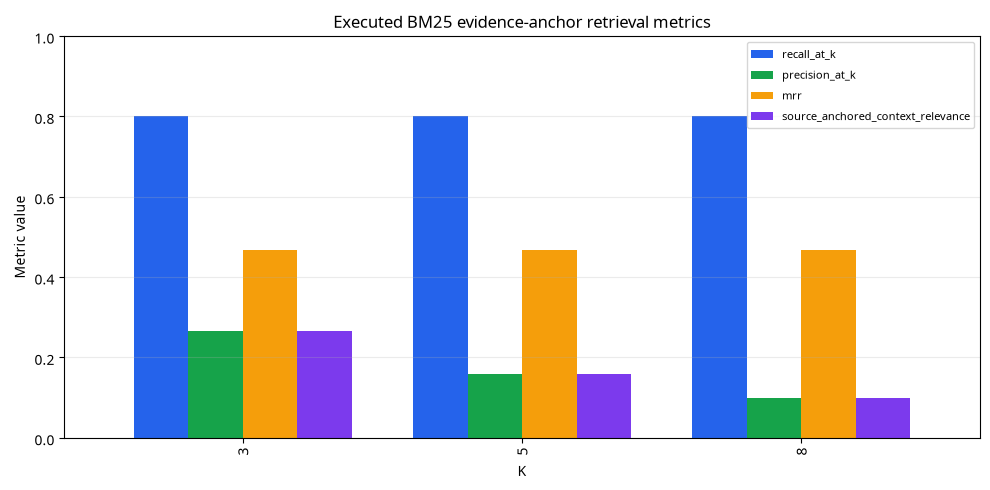

Saved chart: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_evaluation_bm25_metrics.png


In [5]:
PLOT_OUT = PROCESSED_DIR / 'introduction_to_business_evaluation_bm25_metrics.png'
metric_columns = ['recall_at_k', 'precision_at_k', 'mrr', 'source_anchored_context_relevance']
plot_frame = macro_metrics.set_index('k')[metric_columns]
ax = plot_frame.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), width=0.78, color=['#2563eb', '#16a34a', '#f59e0b', '#7c3aed'])
ax.set_title('Executed BM25 evidence-anchor retrieval metrics')
ax.set_xlabel('K')
ax.set_ylabel('Metric value')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_OUT, dpi=160)
plt.show()
print('Saved chart:', PLOT_OUT)


## Generation metrics and Ragas guard

Faithfulness, answer relevance, and context utilization require real generated answers linked to retrieved context. The code below detects whether such artifacts exist before calling Ragas. If there are no real answers, it stores explicit non-evaluation records and **does not create numeric values**.

Context utilization is defined as a custom citation-aware measure: the fraction of answer citations that resolve to a retrieved context chunk. It is only meaningful after real answer and citation artifacts exist.


In [6]:
GENERATION_STATUS_PATHS = [
    PROCESSED_DIR / 'introduction_to_business_llm_generation_status.json',
    PROCESSED_DIR / 'introduction_to_business_prompt_engineering_status.json',
    PROCESSED_DIR / 'introduction_to_business_langgraph_rag_status.json',
]

def json_if_present(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else {'missing': True, 'path': str(path)}

def recursively_collect_real_answers(value) -> list[str]:
    answers = []
    if isinstance(value, dict):
        for key, item in value.items():
            if key in {'answer', 'generated_answer', 'response'} and isinstance(item, str):
                normalized = item.strip()
                if normalized and not normalized.startswith('[') and 'not generated' not in normalized.lower():
                    answers.append(normalized)
            answers.extend(recursively_collect_real_answers(item))
    elif isinstance(value, list):
        for item in value:
            answers.extend(recursively_collect_real_answers(item))
    return answers

generation_statuses = {path.name: json_if_present(path) for path in GENERATION_STATUS_PATHS}
real_answers = [answer for status in generation_statuses.values() for answer in recursively_collect_real_answers(status)]
ragas_package_detected = importlib.util.find_spec('ragas') is not None
ragas_importable = False
ragas_version = None
ragas_import_error = None
if ragas_package_detected:
    try:
        import ragas
        ragas_importable = True
        ragas_version = getattr(ragas, '__version__', 'installed_version_not_exposed')
    except Exception as error:
        ragas_import_error = f'{type(error).__name__}: {error}'

blocked_reasons = []
if not real_answers:
    blocked_reasons.extend([
        'No real generated answers were found in the Phase 09, Phase 10, or Phase 12 status artifacts.',
        'The exact Qwen2.5-7B-Instruct path remains unavailable and OpenStax generative-AI permission is unconfirmed in prior verified records.'
    ])
if not ragas_importable:
    blocked_reasons.append('Ragas is not importable in this environment: ' + (ragas_import_error or 'package not installed'))

generation_preflight = {
    'ragas_package_detected': ragas_package_detected,
    'ragas_importable': ragas_importable,
    'ragas_version': ragas_version,
    'ragas_import_error': ragas_import_error,
    'real_generated_answer_count': len(real_answers),
    'eligible_for_generation_metrics': bool(real_answers) and ragas_importable,
    'blocked_reasons': blocked_reasons,
}
print(json.dumps(generation_preflight, indent=2))


{
  "ragas_package_detected": true,
  "ragas_importable": false,
  "ragas_version": null,
  "ragas_import_error": "ModuleNotFoundError: No module named 'langchain_community.chat_models.vertexai'",
  "real_generated_answer_count": 0,
  "eligible_for_generation_metrics": false,
  "blocked_reasons": [
    "No real generated answers were found in the Phase 09, Phase 10, or Phase 12 status artifacts.",
    "The exact Qwen2.5-7B-Instruct path remains unavailable and OpenStax generative-AI permission is unconfirmed in prior verified records.",
    "Ragas is not importable in this environment: ModuleNotFoundError: No module named 'langchain_community.chat_models.vertexai'"
  ]
}


In [7]:
# Guarded Ragas integration. This block intentionally does not run when preflight is false.
if generation_preflight['eligible_for_generation_metrics']:
    from ragas import evaluate
    from ragas.dataset_schema import EvaluationDataset, SingleTurnSample
    from ragas.metrics import Faithfulness, AnswerRelevancy

    # Populate samples only from actual answer, question, and retrieved-context artifacts.
    # No reference answer is synthesized here. Context utilization remains a custom citation-resolution metric.
    raise RuntimeError('Real answer artifacts exist; provide approved evaluator configuration before running Ragas.')
else:
    print('Ragas execution skipped: no eligible real generation artifacts. No faithfulness, answer-relevance, or context-utilization scores were created.')


Ragas execution skipped: no eligible real generation artifacts. No faithfulness, answer-relevance, or context-utilization scores were created.


## Compare requested pipeline variants

The table separates **evaluated** results from unavailable variants. A null value means no score was computed, not a zero score.


In [8]:
variant_comparison = [
    {
        'variant': 'Dense RAG',
        'retrieval_status': 'not_evaluable',
        'generation_status': 'not_evaluable',
        'reason': 'No real BAAI/bge-m3 embedding artifact exists after the verified resource preflight block.',
    },
    {
        'variant': 'Hybrid RAG',
        'retrieval_status': 'not_evaluable',
        'generation_status': 'not_evaluable',
        'reason': 'Dense retrieval is blocked, so the hybrid fusion artifact was not produced.',
    },
    {
        'variant': 'Hybrid + Reranking',
        'retrieval_status': 'not_evaluable',
        'generation_status': 'not_evaluable',
        'reason': 'No real hybrid candidates exist for BAAI/bge-reranker-v2-m3.',
    },
    {
        'variant': 'RAG + basic prompt',
        'retrieval_status': 'not_evaluable',
        'generation_status': 'not_evaluable',
        'reason': 'No real Qwen answer artifact is available for the basic-prompt path.',
    },
    {
        'variant': 'RAG + prompt engineering',
        'retrieval_status': 'not_evaluable',
        'generation_status': 'not_evaluable',
        'reason': 'Phase 09 defined prompts but recorded no real model answers.',
    },
    {
        'variant': 'Deterministic LangGraph RAG',
        'retrieval_status': 'partially_executed_bm25_only',
        'generation_status': 'not_evaluable',
        'reason': 'The fixed graph executed its BM25 retrieve stage, but reranking and answer generation were blocked by verified prerequisites.',
    },
]

variant_frame = pd.DataFrame(variant_comparison)
variant_frame


,variant,retrieval_status,generation_status,reason
0,Dense RAG,not_evaluable,not_evaluable,No real BAAI/bge-m3 embedding artifact exists ...
1,Hybrid RAG,not_evaluable,not_evaluable,"Dense retrieval is blocked, so the hybrid fusi..."
2,Hybrid + Reranking,not_evaluable,not_evaluable,No real hybrid candidates exist for BAAI/bge-r...
3,RAG + basic prompt,not_evaluable,not_evaluable,No real Qwen answer artifact is available for ...
4,RAG + prompt engineering,not_evaluable,not_evaluable,Phase 09 defined prompts but recorded no real ...
5,Deterministic LangGraph RAG,partially_executed_bm25_only,not_evaluable,The fixed graph executed its BM25 retrieve sta...


In [9]:
generation_metric_record = {
    metric: {
        'value': None,
        'status': 'not_evaluable',
        'reason': '; '.join(generation_preflight['blocked_reasons'])
    }
    for metric in ['faithfulness', 'answer_relevance', 'context_utilization']
}

evaluation_results = {
    'phase': '14_evaluation',
    'source_policy': 'Official OpenStax Introduction to Business evidence anchors only; no fabricated ground-truth answers.',
    'retrieval': {
        'status': 'partially_evaluated',
        'eligible_variant': 'bm25_sparse_baseline',
        'metric_definition': {
            'recall_at_k': 'Whether the direct source-evidence anchor was returned in the first K results.',
            'precision_at_k': 'Evidence-anchor hits divided by K.',
            'mrr': 'Reciprocal rank of the first evidence-anchor hit.',
            'context_relevance': 'Source-anchored context relevance: evidence-anchor hits divided by returned contexts.'
        },
        'per_query': per_query_metric_rows,
        'macro_average': macro_metrics.to_dict(orient='records'),
    },
    'generation': {
        'status': 'not_evaluable',
        'preflight': generation_preflight,
        'metrics': generation_metric_record,
    },
    'requested_variant_comparison': variant_comparison,
    'no_fabrication_assertions': {
        'generated_reference_answers': False,
        'generated_model_answers': False,
        'invented_retrieval_scores': False,
        'invented_generation_scores': False,
    },
}

RESULTS_OUT = PROCESSED_DIR / 'introduction_to_business_evaluation_results.json'
STATUS_OUT = PROCESSED_DIR / 'introduction_to_business_evaluation_status.json'
RESULTS_OUT.write_text(json.dumps(evaluation_results, indent=2, ensure_ascii=False), encoding='utf-8')
STATUS_OUT.write_text(json.dumps({
    'phase': '14_evaluation',
    'status': 'partially_evaluated_real_bm25_only',
    'dataset_status': 'source_anchored_and_verified',
    'retrieval_status': 'BM25 metrics computed from 15 executed runs and five direct source-evidence anchors.',
    'generation_status': 'not_evaluable_no_real_answers',
    'ragas_package_detected': ragas_package_detected,
    'ragas_importable': ragas_importable,
    'outputs': [str(path.relative_to(ROOT)) for path in [DATASET_OUT, RESULTS_OUT, PLOT_OUT]],
    'limitations': generation_preflight['blocked_reasons'] + [
        'Dense, hybrid, and reranked variants cannot be scored without real BGE-M3 embeddings and hybrid/reranker artifacts.'
    ],
}, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved dataset:', DATASET_OUT)
print('Saved results:', RESULTS_OUT)
print('Saved status:', STATUS_OUT)
print('No-fabrication assertions:', evaluation_results['no_fabrication_assertions'])


Saved dataset: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_evaluation_dataset.json
Saved results: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_evaluation_results.json
Saved status: /home/ubuntu/business-knowledge-ai/data/processed/introduction_to_business_evaluation_status.json
No-fabrication assertions: {'generated_reference_answers': False, 'generated_model_answers': False, 'invented_retrieval_scores': False, 'invented_generation_scores': False}


## Interpretation

The resulting BM25 metrics are actual measurements over the five direct source-evidence anchors and the executed Top-K runs. They should not be generalized to dense retrieval, fusion, reranking, prompt variants, or final answer quality. Those paths remain unscored until real artifacts are available.

To enable full evaluation later, retain this same dataset and rerun the notebook after producing real dense, hybrid, reranked, and answer artifacts under confirmed OpenStax generative-AI permission. The notebook will then expose the guarded Ragas path and can add generation metrics without changing any ground-truth policy.
